# EEG_14 — DHSLP: Pretrain S-Indep + Calibrazione per Soggetto (PRE/POST-CAL)

**Schema corretto**:
```
Pretrain: SUBJ_TRAIN (0–49) — TUTTE le sessioni e parole → modello universale
                ↓
  Per ogni soggetto SUBJ_TEST (60–72) [mai visto nel pretrain]:

    Pipeline A — PRE-CAL:
      pretrain model → valutazione su sess.5 (nessun FT)

    Pipeline B — Calibrazione:
      fine-tune su sess.1-2-3 (train) + sess.4 (val) → valutazione su sess.5

    Δ = POST-CAL − PRE-CAL
```

**SUBJ_VAL (50–59)**: usato solo come val durante il pretrain (monitoraggio loss).  
**SUBJ_TEST (60–72)**: soggetti completamente esclusi dal pretrain → calibrazione + confronto.  
**Solo soggetti con ≥ 5 sessioni** entrano nel loop di calibrazione.

In [ ]:
import json, logging, re, traceback
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import balanced_accuracy_score, recall_score
from tqdm.auto import tqdm
import wandb

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('eeg14')

project_root = next((p for p in [Path.cwd()]+list(Path.cwd().parents) if (p/'.git').exists()), Path.cwd())
FIG_DIR  = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)
CKPT_DIR = project_root / 'models' / 'eeg14'; CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ---- CONFIG ----
N_CHANNELS   = 61
N_SAMPLES    = 384
N_CLASSES    = 4
CLUSTER_SCHEME = 'concr4'

K_WINDOWS  = 8
N_EDGES    = 16
D_MODEL    = 64
HIDDEN     = 128
N_LAYERS   = 2
T_WIN      = N_SAMPLES // K_WINDOWS   # 48

# Split soggetti
# SUBJ_TRAIN (0-59): tutte le sessioni → pretrain M
# SUBJ_TEST  (60-72): mai visti nel pretrain → calibrazione PRE/POST-CAL
# Nessun SUBJ_VAL separato — val pretrain = 10% random dei trial di training
SUBJ_TRAIN = list(range(0, 60))   # 60 soggetti per M (ex SUBJ_VAL ora incluso)
SUBJ_TEST  = list(range(60, 74))  # 13 soggetti per calibrazione

PRETRAIN_VAL_FRAC = 0.10   # 10% dei trial train usati come val pretrain

# --- CONFIG PRETRAIN ---
PRETRAIN_DROPOUT       = 0.4
PRETRAIN_LR            = 1e-3
PRETRAIN_WEIGHT_DECAY  = 3e-3
PRETRAIN_BATCH_SIZE    = 64
PRETRAIN_MAX_EPOCHS    = 60
PRETRAIN_PATIENCE      = 12
PRETRAIN_LABEL_SMOOTH  = 0.15
PRETRAIN_GRAD_CLIP     = 1.0

PRETRAIN_CKPT = CKPT_DIR / 'pretrain_E16_d64.pt'

# --- CONFIG CALIBRAZIONE ---
FT_TRAIN_SESSIONS = [1, 2, 3]
FT_VAL_SESSION    = 4
FT_TEST_SESSION   = 5

FT_DROPOUT       = 0.5
FT_LR            = 1e-4
FT_WEIGHT_DECAY  = 1e-2
FT_BATCH_SIZE    = 32
FT_MAX_EPOCHS    = 40
FT_PATIENCE      = 8
FT_LABEL_SMOOTH  = 0.15
FT_GRAD_CLIP     = 1.0
USE_INSTANCE_NORM = True

DATA_METRIC   = 'abs_pcc'
WANDB_ENTITY  = 'uras-daniele22-politecnico-di-milano'
WANDB_PROJECT = 'miralis-imagined-speech'

_PAT = re.compile(r'^P(\d+)_S(\d+)$')
label2cluster = {int(k): int(v) for k,v in json.loads(
    (project_root/'configs'/'label_schemes'/'labelid2cluster_concr4.json').read_text()).items()}

HG_ROOT = project_root / 'data' / f'hypergraphs_pruned_{DATA_METRIC}'
subj_sess = defaultdict(lambda: defaultdict(list))
for p in sorted(HG_ROOT.rglob('trial_*.pt')):
    m = _PAT.match(p.parent.name)
    if m:
        subj_sess[int(m.group(1))][int(m.group(2))].append(p)

ALL_SUBJ = sorted(subj_sess.keys())

SUBJ_CAL = [s for s in SUBJ_TEST if s in subj_sess and
            all(ses in subj_sess[s] for ses in FT_TRAIN_SESSIONS + [FT_VAL_SESSION, FT_TEST_SESSION])]

log.info(f'SUBJ_TRAIN={len(SUBJ_TRAIN)} sogg. (0-59) — pretrain M (tutte le sessioni)')
log.info(f'SUBJ_TEST ={len(SUBJ_TEST)} sogg. (60-72) — mai visti nel pretrain')
log.info(f'SUBJ_CAL  ={len(SUBJ_CAL)} sogg. con ≥5 sessioni → candidati calibrazione')
log.info(f'Pretrain val: {int(PRETRAIN_VAL_FRAC*100)}% random split dai trial di training')
log.info(f'PRETRAIN: DO={PRETRAIN_DROPOUT}  WD={PRETRAIN_WEIGHT_DECAY}  LS={PRETRAIN_LABEL_SMOOTH}')
log.info(f'FT:       DO={FT_DROPOUT}  WD={FT_WEIGHT_DECAY}  LR={FT_LR}')

## §1 — Dataset

In [ ]:
class EEGRawDatasetSS(Dataset):
    """Carica x (61,384) e y da lista di (path, label). H ignorata."""
    def __init__(self, paths_and_labels, use_instance_norm=True):
        self.items = paths_and_labels
        self.use_instance_norm = use_instance_norm

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        p, label = self.items[idx]
        d = torch.load(p, weights_only=False)
        x = d['x'].float()
        if self.use_instance_norm:
            x = (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-6)
        return x, torch.tensor(label, dtype=torch.long)


def _collect(subj_ids, sessions=None):
    items = []
    for sid in subj_ids:
        sess_keys = list(subj_sess[sid].keys()) if sessions is None else sessions
        for s in sess_keys:
            for p in subj_sess[sid].get(s, []):
                d = torch.load(p, weights_only=False)
                y_word = int(d['y'].squeeze()) if isinstance(d['y'], torch.Tensor) else int(d['y'])
                c = label2cluster.get(y_word)
                if c is not None:
                    items.append((p, c))
    return items


def make_weighted_loader(items, batch_size):
    labels   = np.array([it[1] for it in items])
    counts   = np.bincount(labels, minlength=N_CLASSES)
    sample_w = torch.tensor(1.0 / counts[labels], dtype=torch.float)
    sampler  = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)
    return DataLoader(EEGRawDatasetSS(items, USE_INSTANCE_NORM), batch_size,
                      sampler=sampler, num_workers=0, pin_memory=False)


def make_plain_loader(items, batch_size):
    return DataLoader(EEGRawDatasetSS(items, USE_INSTANCE_NORM), batch_size,
                      shuffle=False, num_workers=0, pin_memory=False)


# ---- Pretrain loaders: SUBJ_TRAIN (0-59) tutte sessioni, val=10% random ----

def make_pretrain_loaders(val_frac=PRETRAIN_VAL_FRAC, seed=42):
    all_items = _collect(SUBJ_TRAIN, sessions=None)
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(all_items))
    n_val = int(len(all_items) * val_frac)
    va_items = [all_items[i] for i in idx[:n_val]]
    tr_items = [all_items[i] for i in idx[n_val:]]
    log.info(f'Pretrain  train: {len(tr_items)} trial  ({len(SUBJ_TRAIN)} sogg., tutte sessioni)')
    log.info(f'Pretrain  val:   {len(va_items)} trial  ({val_frac*100:.0f}% random split)')
    return make_weighted_loader(tr_items, PRETRAIN_BATCH_SIZE), \
           make_plain_loader(va_items,   PRETRAIN_BATCH_SIZE)


# ---- Calibrazione loaders: soggetto test, split fisso sessioni ----

def make_cal_loaders(subj_id):
    """sess.1-2-3 train | sess.4 val | sess.5 test (PRE e POST-CAL)"""
    tr_items = _collect([subj_id], FT_TRAIN_SESSIONS)
    va_items = _collect([subj_id], [FT_VAL_SESSION])
    te_items = _collect([subj_id], [FT_TEST_SESSION])
    if not tr_items or not te_items:
        return None
    return (make_weighted_loader(tr_items, FT_BATCH_SIZE),
            make_plain_loader(va_items,    FT_BATCH_SIZE),
            make_plain_loader(te_items,    FT_BATCH_SIZE))


log.info('Dataset OK')

## §2 — Modello DHSLP

In [ ]:
class HGNNConv(nn.Module):
    """HGNN spectral convolution layer (Feng et al. 2019) — batched."""
    def __init__(self, in_ch, out_ch, bias=True):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_ch, out_ch))
        self.bias   = nn.Parameter(torch.zeros(out_ch)) if bias else None
        nn.init.xavier_uniform_(self.weight)

    def forward(self, X, H):
        # X: (B,N,C)  H: (B,N,E) — soft incidence matrix dinamica
        d_v = H.sum(dim=2).clamp(min=1e-6)
        d_e = H.sum(dim=1).clamp(min=1e-6)
        Dv  = (1.0 / d_v.sqrt()).unsqueeze(-1)
        De  = (1.0 / d_e).unsqueeze(1)
        out = Dv * (X @ self.weight)
        out = torch.bmm(H.transpose(1, 2), out)
        out = De.transpose(1, 2) * out
        out = torch.bmm(H, out)
        out = Dv * out
        if self.bias is not None: out = out + self.bias
        return out


class DHSLP(nn.Module):
    """
    Dynamic Hypergraph Spectral Learning with Positional encoding.
    Ispirato a Li et al. 2025.

    Input:  x (B, 61, 384)  — nessuna H in input
    Output: logits (B, 4)

    Pipeline per finestra temporale k:
      feat_k = Linear(x_k) + pos_enc        → (B, 61, d)
      H_k    = softmax(feat_k @ E^T / √d)   → (B, 61, n_edges)  [DINAMICA]
      out_k  = HGNNConv(feat_k, H_k).mean   → (B, hidden)
    z = mean(out_1..K) → Linear → logits
    """
    def __init__(self, n_nodes=N_CHANNELS, T_win=T_WIN, K=K_WINDOWS,
                 n_edges=N_EDGES, d_model=D_MODEL, hidden=HIDDEN,
                 n_classes=N_CLASSES, n_layers=N_LAYERS, dropout=0.3):
        super().__init__()
        self.K, self.T_win, self.d_model = K, T_win, d_model

        # Learnable iperedge embeddings — E ∈ R^{n_edges × d}
        self.E = nn.Parameter(torch.randn(n_edges, d_model) * 0.01)
        # Encoding posizionale per elettrodo — pos_enc ∈ R^{61 × d}
        self.pos_enc = nn.Parameter(torch.randn(n_nodes, d_model) * 0.01)

        self.node_proj = nn.Sequential(
            nn.Linear(T_win, d_model),
            nn.LayerNorm(d_model),
            nn.ELU(),
        )
        dims = [d_model] + [hidden] * n_layers
        self.convs = nn.ModuleList([HGNNConv(dims[i], dims[i+1]) for i in range(n_layers)])
        self.bns   = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(n_layers)])
        self.drop  = nn.Dropout(dropout)
        self.clf   = nn.Linear(hidden, n_classes)

    def build_dynamic_H(self, feat):
        """feat: (B,N,d)  →  H: (B,N,n_edges) — soft assignment nodo→iperedge."""
        scores = torch.matmul(feat, self.E.T) / (self.d_model ** 0.5)
        return torch.softmax(scores, dim=2)

    def forward(self, x):
        B, N, T = x.shape
        outs = []
        for k in range(self.K):
            x_k  = x[:, :, k*self.T_win:(k+1)*self.T_win]   # (B,N,T_win)
            feat = self.node_proj(x_k) + self.pos_enc        # (B,N,d)
            H_k  = self.build_dynamic_H(feat)                # (B,N,n_edges)
            out  = feat
            for conv, bn in zip(self.convs, self.bns):
                out = conv(out, H_k)
                out = bn(out.reshape(B*N, -1)).reshape(B, N, -1)
                out = F.relu(out)
                out = self.drop(out)
            outs.append(out.mean(dim=1))   # (B, hidden)
        return self.clf(torch.stack(outs, dim=1).mean(dim=1))


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
log.info(f'device: {device}')

# Sanity check architettura
_m = DHSLP(dropout=PRETRAIN_DROPOUT)
_x = torch.randn(4, N_CHANNELS, N_SAMPLES)
assert _m(_x).shape == (4, N_CLASSES)
n_p = sum(p.numel() for p in _m.parameters() if p.requires_grad)
log.info(f'DHSLP OK — {n_p:,} parametri  K={K_WINDOWS} N_EDGES={N_EDGES} D_MODEL={D_MODEL}')
del _m, _x

## §3 — Pretrain S-Indep

**Identico a EEG_13** (SUBJ_TRAIN=0–49). Salva checkpoint su disco per il fine-tuning.

Se `PRETRAIN_CKPT` esiste già, questo step può essere saltato (`SKIP_PRETRAIN = True`).

In [ ]:
# SKIP_PRETRAIN = True   # imposta True per riusare checkpoint su disco
SKIP_PRETRAIN = False

if SKIP_PRETRAIN:
    log.info(f'Skip pretrain — uso checkpoint: {PRETRAIN_CKPT}')
else:
    log.info('=== PRETRAIN (SUBJ_TRAIN 0-59, tutte le sessioni) ===')
    pt_tr_loader, pt_va_loader = make_pretrain_loaders()

    pretrain_model = DHSLP(dropout=PRETRAIN_DROPOUT).to(device)
    pt_criterion   = nn.CrossEntropyLoss(label_smoothing=PRETRAIN_LABEL_SMOOTH)
    pt_optimizer   = torch.optim.Adam(pretrain_model.parameters(),
                                      lr=PRETRAIN_LR, weight_decay=PRETRAIN_WEIGHT_DECAY)
    pt_sched       = torch.optim.lr_scheduler.CosineAnnealingLR(pt_optimizer, T_max=PRETRAIN_MAX_EPOCHS)

    pt_run = wandb.init(
        entity=WANDB_ENTITY, project=WANDB_PROJECT,
        name=f'eeg14_pretrain_v3_DHSLP_{CLUSTER_SCHEME}',
        config=dict(
            notebook='EEG_14', phase='pretrain_v3', model='DHSLP',
            n_classes=N_CLASSES, cluster_scheme=CLUSTER_SCHEME,
            k_windows=K_WINDOWS, n_edges=N_EDGES, d_model=D_MODEL,
            dropout=PRETRAIN_DROPOUT, lr=PRETRAIN_LR,
            weight_decay=PRETRAIN_WEIGHT_DECAY,
            label_smoothing=PRETRAIN_LABEL_SMOOTH,
            grad_clip=PRETRAIN_GRAD_CLIP,
            batch_size=PRETRAIN_BATCH_SIZE, max_epochs=PRETRAIN_MAX_EPOCHS,
            n_train_subj=len(SUBJ_TRAIN),
            pretrain_val_frac=PRETRAIN_VAL_FRAC,
            pretrain_sessions='all',
        ),
        reinit='finish_previous',
        settings=wandb.Settings(start_method='thread')
    )

    pt_best_val, pt_best_state, pt_patience = 0.0, None, 0

    def _run_epoch_pt(model, loader, optimizer=None):
        train = optimizer is not None
        model.train() if train else model.eval()
        total_loss, all_lbl, all_pred = 0.0, [], []
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss   = pt_criterion(logits, y)
                if train:
                    optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), PRETRAIN_GRAD_CLIP)
                    optimizer.step()
                total_loss += loss.item() * len(y)
                all_lbl.extend(y.cpu().numpy())
                all_pred.extend(logits.argmax(1).cpu().numpy())
        return total_loss / len(loader.dataset), balanced_accuracy_score(all_lbl, all_pred)

    for epoch in range(1, PRETRAIN_MAX_EPOCHS + 1):
        tr_loss, tr_b = _run_epoch_pt(pretrain_model, pt_tr_loader, pt_optimizer)
        va_loss, va_b = _run_epoch_pt(pretrain_model, pt_va_loader)
        pt_sched.step()
        pt_run.log({'train/loss': tr_loss, 'train/bacc': tr_b,
                    'val/loss': va_loss,   'val/bacc': va_b, 'epoch': epoch})
        if va_b > pt_best_val:
            pt_best_val = va_b
            pt_best_state = {k: v.cpu().clone() for k, v in pretrain_model.state_dict().items()}
            pt_patience = 0
        else:
            pt_patience += 1
        if pt_patience >= PRETRAIN_PATIENCE:
            log.info(f'  early stop @ epoch {epoch}'); break
        if epoch % 10 == 0:
            log.info(f'  Epoch {epoch:3d}: train={tr_b:.4f}  val={va_b:.4f}  best={pt_best_val:.4f}')

    pt_run.summary['val_bacc'] = pt_best_val
    pt_run.finish()

    torch.save({'state_dict': pt_best_state, 'val_bacc': pt_best_val,
                'config': dict(n_edges=N_EDGES, d_model=D_MODEL, k_windows=K_WINDOWS,
                               hidden=HIDDEN, n_layers=N_LAYERS, dropout=PRETRAIN_DROPOUT)},
               PRETRAIN_CKPT)
    log.info(f'Salvato: {PRETRAIN_CKPT}  best_val={pt_best_val:.4f}')

## §4 — Calibrazione per Soggetto (Fine-Tune + PRE/POST-CAL)

Per ogni soggetto con ≥ 5 sessioni:
1. **PRE-CAL**: evalua il modello pretrain su sessione 5 senza modifiche
2. **Fine-Tune**: adatta i pesi su sessioni 1-2-3, monitora su sessione 4
3. **POST-CAL**: evalua il modello calibrato su sessione 5
4. **Δ** = POST-CAL − PRE-CAL → misura il guadagno dalla calibrazione

In [ ]:
ft_criterion = nn.CrossEntropyLoss(label_smoothing=FT_LABEL_SMOOTH)


def run_epoch_ft(model, loader, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total_loss, all_lbl, all_pred = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss   = ft_criterion(logits, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), FT_GRAD_CLIP)
                optimizer.step()
            total_loss += loss.item() * len(y)
            all_lbl.extend(y.cpu().numpy())
            all_pred.extend(logits.argmax(1).cpu().numpy())
    bacc = balanced_accuracy_score(all_lbl, all_pred)
    return total_loss / len(loader.dataset), bacc, np.array(all_lbl), np.array(all_pred)


def load_pretrain_model(dropout=FT_DROPOUT):
    if not PRETRAIN_CKPT.exists():
        raise FileNotFoundError(f'Checkpoint non trovato: {PRETRAIN_CKPT} — esegui §3 prima.')
    ckpt = torch.load(PRETRAIN_CKPT, weights_only=False)
    model = DHSLP(dropout=dropout)
    model.load_state_dict(ckpt['state_dict'])
    return model.to(device)


def calibrate_subject(subj_id, tr_l, va_l, te_l):
    run_name = f'eeg14_DHSLP_CAL_P{subj_id:03d}_{CLUSTER_SCHEME}'

    # ---- PRE-CAL: pretrain model su sessione 5, senza fine-tuning ----
    pretrain_model_eval = load_pretrain_model(dropout=0.0)  # dropout=0 in eval
    _, pre_cal_bacc, pre_lbl, pre_pred = run_epoch_ft(pretrain_model_eval, te_l)
    log.info(f'  P{subj_id:03d} PRE-CAL: {pre_cal_bacc:.4f}')
    del pretrain_model_eval

    # ---- FINE-TUNE ----
    cfg = dict(
        notebook='EEG_14', phase='calibration', model='DHSLP_CAL',
        subject=f'P{subj_id:03d}',
        n_classes=N_CLASSES, cluster_scheme=CLUSTER_SCHEME,
        k_windows=K_WINDOWS, n_edges=N_EDGES, d_model=D_MODEL,
        dropout=FT_DROPOUT, lr=FT_LR, weight_decay=FT_WEIGHT_DECAY,
        label_smoothing=FT_LABEL_SMOOTH, grad_clip=FT_GRAD_CLIP,
        batch_size=FT_BATCH_SIZE, max_epochs=FT_MAX_EPOCHS,
        train_sessions=FT_TRAIN_SESSIONS,
        val_session=FT_VAL_SESSION, test_session=FT_TEST_SESSION,
        pre_cal_bacc=round(pre_cal_bacc, 4),
        n_train=len(tr_l.dataset),
    )
    run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT,
                     name=run_name, config=cfg, reinit='finish_previous',
                     settings=wandb.Settings(start_method='thread'))
    run.log({'pre_cal/bacc': pre_cal_bacc})

    model = load_pretrain_model(dropout=FT_DROPOUT)
    opt   = torch.optim.Adam(model.parameters(), lr=FT_LR, weight_decay=FT_WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=FT_MAX_EPOCHS)
    best_val, best_state, patience_cnt = 0.0, None, 0

    for epoch in range(1, FT_MAX_EPOCHS + 1):
        tr_loss, tr_b, _, _ = run_epoch_ft(model, tr_l, opt)
        va_loss, va_b, _, _ = run_epoch_ft(model, va_l)
        sched.step()
        run.log({'train/loss': tr_loss, 'train/bacc': tr_b,
                 'val/loss': va_loss,   'val/bacc': va_b, 'epoch': epoch})
        if va_b > best_val:
            best_val = va_b
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
        if patience_cnt >= FT_PATIENCE:
            log.info(f'  P{subj_id:03d} early stop @ epoch {epoch}'); break

    model.load_state_dict(best_state)
    _, post_cal_bacc, te_lbl, te_pred = run_epoch_ft(model, te_l)
    delta = post_cal_bacc - pre_cal_bacc

    # Checkpoint
    ckpt_path = CKPT_DIR / f'P{subj_id:03d}.pt'
    torch.save({'state_dict': best_state,
                'val_bacc': best_val,
                'pre_cal_bacc': pre_cal_bacc,
                'post_cal_bacc': post_cal_bacc,
                'delta': delta,
                'labels': te_lbl, 'preds': te_pred}, ckpt_path)

    run.summary['val_bacc']      = best_val
    run.summary['pre_cal_bacc']  = pre_cal_bacc
    run.summary['post_cal_bacc'] = post_cal_bacc
    run.summary['delta_bacc']    = delta
    run.log({'post_cal/bacc': post_cal_bacc, 'delta/bacc': delta})
    run.log({'confusion_matrix': wandb.plot.confusion_matrix(
        preds=te_pred.tolist(), y_true=te_lbl.tolist(),
        class_names=['CONCR', 'AZIONE', 'STATO', 'ASTRATTO'])})
    run.finish()

    log.info(f'  P{subj_id:03d}: PRE={pre_cal_bacc:.4f}  POST={post_cal_bacc:.4f}  Δ={delta:+.4f}')
    return {'pre_cal_bacc': pre_cal_bacc, 'post_cal_bacc': post_cal_bacc,
            'val_bacc': best_val, 'delta': delta, 'labels': te_lbl, 'preds': te_pred}

## §5 — Loop su Tutti i Soggetti

In [ ]:
SUBJECT_RESULTS = {}

if not PRETRAIN_CKPT.exists():
    log.error(f'Checkpoint pretrain non trovato: {PRETRAIN_CKPT} — esegui §3 prima.')
else:
    log.info(f'=== CALIBRAZIONE — {len(SUBJ_CAL)} soggetti test con ≥5 sessioni ===')
    log.info(f'Split: sess.{FT_TRAIN_SESSIONS} train / sess.{FT_VAL_SESSION} val / sess.{FT_TEST_SESSION} test')

    for sid in tqdm(SUBJ_CAL, desc='Calibrazione DHSLP'):
        loaders = make_cal_loaders(sid)
        if loaders is None:
            log.warning(f'P{sid:03d}: skip')
            continue
        tr_l, va_l, te_l = loaders
        log.info(f'P{sid:03d}: train={len(tr_l.dataset)} val={len(va_l.dataset)} test={len(te_l.dataset)}')
        try:
            SUBJECT_RESULTS[sid] = calibrate_subject(sid, tr_l, va_l, te_l)
        except Exception as e:
            log.error(f'P{sid:03d}: {e}\n{traceback.format_exc()}')

    log.info(f'\n=== DONE: {len(SUBJECT_RESULTS)}/{len(SUBJ_CAL)} soggetti ===')

## §6 — Ricarica da Checkpoint + Ranking

In [9]:
if not SUBJECT_RESULTS:
    log.info('Ricarico da checkpoint...')
    for ckpt in sorted(CKPT_DIR.glob('P*.pt')):
        sid = int(ckpt.stem[1:])
        d = torch.load(ckpt, weights_only=False)
        SUBJECT_RESULTS[sid] = {k: d[k] for k in
            ('pre_cal_bacc', 'post_cal_bacc', 'delta', 'val_bacc', 'labels', 'preds')}
    log.info(f'Ricaricati {len(SUBJECT_RESULTS)} soggetti')

if not SUBJECT_RESULTS:
    print('[INFO] Nessun risultato — esegui prima §3 + §5.')
else:
    chance = 1 / N_CLASSES
    rows = []
    for sid, res in SUBJECT_RESULTS.items():
        rows.append({
            'Subject':      f'P{sid:03d}',
            'PRE-CAL':      round(res['pre_cal_bacc'], 4),
            'POST-CAL':     round(res['post_cal_bacc'], 4),
            'Delta':        round(res['delta'], 4),
        })

    df_res = pd.DataFrame(rows).sort_values('POST-CAL', ascending=False).reset_index(drop=True)
    df_res.to_csv(FIG_DIR / 'eeg14_subject_ranking.csv', index=False)

    print('Top-10 by POST-CAL bAcc:')
    print(df_res.head(10).to_string(index=False))
    print(f'\nPRE-CAL  — Mean: {df_res["PRE-CAL"].mean():.4f}  % sopra chance: {(df_res["PRE-CAL"] > chance).mean()*100:.1f}%')
    print(f'POST-CAL — Mean: {df_res["POST-CAL"].mean():.4f}  % sopra chance: {(df_res["POST-CAL"] > chance).mean()*100:.1f}%')
    print(f'Delta    — Mean: {df_res["Delta"].mean():+.4f}   Migliorati: {(df_res["Delta"] > 0).sum()}/{len(df_res)}')

Top-10 by POST-CAL bAcc:
Subject  PRE-CAL  POST-CAL   Delta
   P062   0.3318    0.3403  0.0085
   P064   0.2822    0.2885  0.0063
   P063   0.2761    0.2811  0.0050
   P071   0.2599    0.2696  0.0097
   P060   0.3476    0.2606 -0.0870
   P066   0.2200    0.2600  0.0400
   P061   0.2920    0.2546 -0.0374
   P065   0.2538    0.2336 -0.0203
   P070   0.2453    0.2324 -0.0129
   P072   0.1993    0.2198  0.0205

PRE-CAL  — Mean: 0.2729  % sopra chance: 76.9%
POST-CAL — Mean: 0.2483  % sopra chance: 53.8%
Delta    — Mean: -0.0246   Migliorati: 6/13


## §7 — Bar Chart Ranking

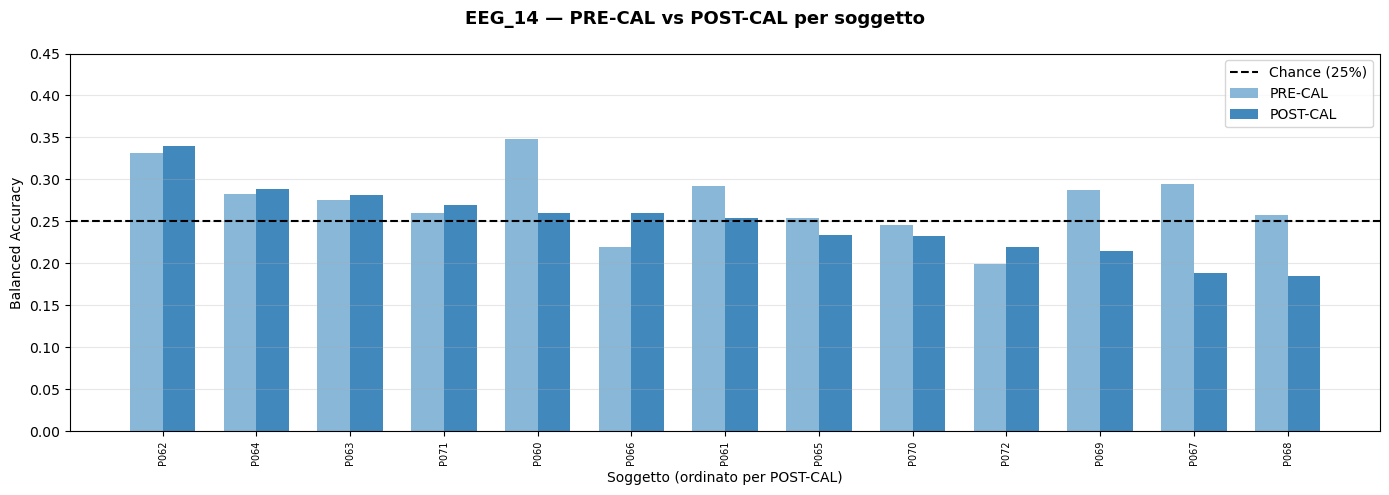

15:50:28 INFO     Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg14_pre_post_bar.png


In [10]:
if 'df_res' not in dir():
    print('[INFO] Esegui prima §6.')
else:
    chance = 1 / N_CLASSES

    fig, ax = plt.subplots(figsize=(14, 5))
    fig.suptitle('EEG_14 — PRE-CAL vs POST-CAL per soggetto', fontsize=13, fontweight='bold')

    x = np.arange(len(df_res))
    w = 0.35
    bars_pre  = ax.bar(x - w/2, df_res['PRE-CAL'],  w, label='PRE-CAL',  color='#7bafd4', alpha=0.9)
    bars_post = ax.bar(x + w/2, df_res['POST-CAL'], w, label='POST-CAL', color='#2C7BB6', alpha=0.9)
    ax.axhline(chance, color='black', linestyle='--', linewidth=1.5, label=f'Chance ({chance:.0%})')
    ax.set_xticks(x)
    ax.set_xticklabels(df_res['Subject'], rotation=90, fontsize=7)
    ax.set_xlabel('Soggetto (ordinato per POST-CAL)')
    ax.set_ylabel('Balanced Accuracy')
    ax.set_ylim(0, max(df_res['POST-CAL'].max() + 0.05, 0.45))
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    out = FIG_DIR / 'eeg14_pre_post_bar.png'
    plt.savefig(out, dpi=150); plt.show()
    log.info(f'Salvato: {out}')

## §8 — Confronto EEG_14 vs EEG_13b

**Delta plot**: EEG_14 (pretrain+FT) − EEG_13b (da zero) per ogni soggetto.
- Barra **verde** (Δ > 0): il pretrain ha aiutato
- Barra **rossa** (Δ < 0): fine-tuning ha peggiorato rispetto a training da zero

Tabella laterale: top-15 soggetti con maggior miglioramento.

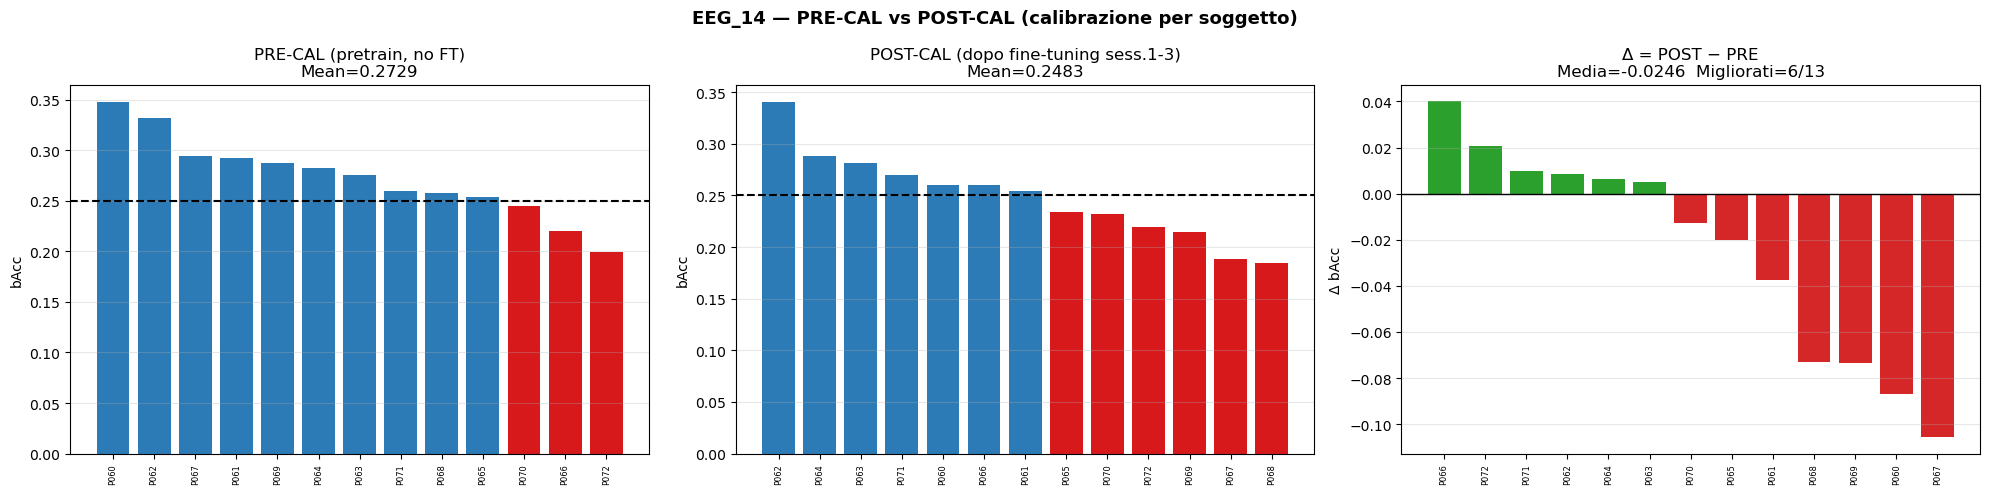

15:50:31 INFO     Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg14_pre_post_cal.png


In [11]:
if 'df_res' not in dir():
    print('[INFO] Esegui prima §6.')
else:
    chance = 1 / N_CLASSES
    df_sorted = df_res.sort_values('Delta', ascending=False)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle('EEG_14 — PRE-CAL vs POST-CAL (calibrazione per soggetto)', fontsize=13, fontweight='bold')

    # Panel 1: PRE-CAL bar chart
    colors_pre = ['#2C7BB6' if v > chance else '#D7191C' for v in df_res.sort_values('PRE-CAL', ascending=False)['PRE-CAL']]
    df_pre = df_res.sort_values('PRE-CAL', ascending=False)
    axes[0].bar(range(len(df_pre)), df_pre['PRE-CAL'], color=colors_pre, width=0.8)
    axes[0].axhline(chance, color='black', linestyle='--', linewidth=1.5)
    axes[0].set_xticks(range(len(df_pre)))
    axes[0].set_xticklabels(df_pre['Subject'], rotation=90, fontsize=6)
    axes[0].set_title(f'PRE-CAL (pretrain, no FT)\nMean={df_res["PRE-CAL"].mean():.4f}')
    axes[0].set_ylabel('bAcc'); axes[0].grid(axis='y', alpha=0.3)

    # Panel 2: POST-CAL bar chart
    colors_post = ['#2C7BB6' if v > chance else '#D7191C' for v in df_res['POST-CAL']]
    axes[1].bar(range(len(df_res)), df_res['POST-CAL'], color=colors_post, width=0.8)
    axes[1].axhline(chance, color='black', linestyle='--', linewidth=1.5)
    axes[1].set_xticks(range(len(df_res)))
    axes[1].set_xticklabels(df_res['Subject'], rotation=90, fontsize=6)
    axes[1].set_title(f'POST-CAL (dopo fine-tuning sess.1-3)\nMean={df_res["POST-CAL"].mean():.4f}')
    axes[1].set_ylabel('bAcc'); axes[1].grid(axis='y', alpha=0.3)

    # Panel 3: Delta bar chart
    delta_colors = ['#2ca02c' if d > 0 else '#d62728' for d in df_sorted['Delta']]
    axes[2].bar(range(len(df_sorted)), df_sorted['Delta'], color=delta_colors, width=0.8)
    axes[2].axhline(0, color='black', linewidth=1.0)
    axes[2].set_xticks(range(len(df_sorted)))
    axes[2].set_xticklabels(df_sorted['Subject'], rotation=90, fontsize=6)
    n_imp = (df_res['Delta'] > 0).sum()
    axes[2].set_title(f'Δ = POST − PRE\nMedia={df_res["Delta"].mean():+.4f}  Migliorati={n_imp}/{len(df_res)}')
    axes[2].set_ylabel('Δ bAcc'); axes[2].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    out = FIG_DIR / 'eeg14_pre_post_cal.png'
    plt.savefig(out, dpi=150); plt.show()
    log.info(f'Salvato: {out}')

## §9 — Analisi Soggetti 'Sleeper' e Interpretazione

I soggetti per cui il pretrain aiuta di più sono potenzialmente "universally decodable" —
il loro segnale EEG ha caratteristiche che il modello generalista ha già visto nel training set.

In [12]:
if 'df_cmp' not in dir():
    print('[INFO] Esegui prima §8.')
else:
    chance = 1 / N_CLASSES

    # Soggetti che escono da chance solo con il pretrain
    unlocked = df_cmp[(df_cmp['EEG_13b'] <= chance) & (df_cmp['EEG_14'] > chance)]
    # Soggetti che regrediscono sotto chance col fine-tuning
    regressed = df_cmp[(df_cmp['EEG_13b'] > chance) & (df_cmp['EEG_14'] <= chance)]
    # Soggetti sopra chance in entrambi i modelli
    both_above = df_cmp[(df_cmp['EEG_13b'] > chance) & (df_cmp['EEG_14'] > chance)]

    print('='*60)
    print('ANALISI COMPARATIVA EEG_14 vs EEG_13b')
    print('='*60)
    print(f'\n[A] Soggetti SBLOCCATI dal pretrain (era ≤ chance, ora > chance):')
    if len(unlocked) > 0:
        print(unlocked[['Subject','EEG_13b','EEG_14','Delta']].to_string(index=False))
    else:
        print('  Nessuno.')

    print(f'\n[B] Soggetti REGREDITI dal fine-tuning (era > chance, ora ≤ chance):')
    if len(regressed) > 0:
        print(regressed[['Subject','EEG_13b','EEG_14','Delta']].to_string(index=False))
    else:
        print('  Nessuno.')

    print(f'\n[C] Sopra chance in ENTRAMBI i modelli ({len(both_above)} soggetti):')
    print(both_above[['Subject','EEG_13b','EEG_14','Delta']].sort_values('EEG_14', ascending=False).to_string(index=False))

    print(f'\n[D] Statistiche aggregate:')
    print(f'  EEG_13b — Mean: {df_cmp["EEG_13b"].mean():.4f}  Median: {df_cmp["EEG_13b"].median():.4f}  % sopra chance: {(df_cmp["EEG_13b"] > chance).mean()*100:.1f}%')
    print(f'  EEG_14  — Mean: {df_cmp["EEG_14"].mean():.4f}  Median: {df_cmp["EEG_14"].median():.4f}  % sopra chance: {(df_cmp["EEG_14"] > chance).mean()*100:.1f}%')
    print(f'  Delta   — Mean: {df_cmp["Delta"].mean():+.4f}  Median: {df_cmp["Delta"].median():+.4f}')

    print('\n[INTERPRETAZIONE]')
    if df_cmp['Delta'].mean() > 0.005:
        print('  → Il pretrain migliora sistematicamente. Le rappresentazioni S-Indep')
        print('    sono un punto di partenza più informativo di random init.')
    elif df_cmp['Delta'].mean() < -0.005:
        print('  → Il fine-tuning peggiora rispetto a training da zero.')
        print('    Probabile causa: LR_FT ancora troppo alto, oppure')
        print('    le rappresentazioni S-Indep non sono allineate con il segnale individuale.')
    else:
        print('  → Delta ≈ 0: il pretrain non porta beneficio significativo.')
        print('    Interpretazione: con ~330 trial/sogg., i pesi S-Indep vengono')
        print('    rapidamente sovrascritti → same regime del training da zero.')
        print('    Possibile soluzione: freeze encoder, fine-tune solo clf head.')

[INFO] Esegui prima §8.
